<a href="https://colab.research.google.com/github/yinyue31/BA820-Team6-Project/blob/main/Yue_Yin_Project_M4_BA820.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Load the Data**

In [1]:
from google.colab import data_table
from google.colab import drive
data_table.enable_dataframe_formatter()
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
cats_uk = pd.read_csv(
    "/content/drive/MyDrive/BA820 Team 6/cats_uk.csv"
)
cats_uk_ref = pd.read_csv(
    "/content/drive/MyDrive/BA820 Team 6/cats_uk_reference.csv"
)

**2.Preprocessing**

In [3]:
#get datetime
import pandas as pd
cats_uk["timestamp"] = pd.to_datetime(cats_uk["timestamp"])

In [4]:
#week alignment
cats_uk["weekday"] = cats_uk["timestamp"].dt.weekday
cats_uk["week_start"] = (
    cats_uk["timestamp"] - pd.to_timedelta(cats_uk["weekday"], unit="D")
).dt.normalize()
# I used AI assistance to implement the weekly grouping logic.I understood and verified how the weekday extraction and week alignment work.

In [5]:
weekly_summary = (
    cats_uk.groupby('week_start')
      .agg(
          n_events=('event_id', 'count'),
          n_cats=('tag_id', 'nunique')
      )
      .reset_index()
)

In [6]:
weekly_summary.sort_values(
    ["n_cats", "n_events"],
    ascending=False
)

,week_start,n_events,n_cats
6,2017-07-17 00:00:00+00:00,2058,21
5,2017-07-10 00:00:00+00:00,1607,18
7,2017-07-24 00:00:00+00:00,2056,17
11,2017-08-28 00:00:00+00:00,1374,16
4,2017-07-03 00:00:00+00:00,1318,16
10,2017-08-21 00:00:00+00:00,711,15
15,2017-09-25 00:00:00+00:00,1270,14
14,2017-09-18 00:00:00+00:00,1665,11
3,2017-06-26 00:00:00+00:00,998,11
13,2017-09-11 00:00:00+00:00,1292,10


In [7]:
#normalizing
week1_start = pd.to_datetime("2017-07-03", utc=True)
week2_start = pd.to_datetime("2017-08-28", utc=True)
week3_start = pd.to_datetime("2017-09-25", utc=True)

w1 = cats_uk[cats_uk["week_start"] == week1_start].copy()
w2 = cats_uk[cats_uk["week_start"] == week2_start].copy()
w3 = cats_uk[cats_uk["week_start"] == week3_start].copy()

w1["hour"] = w1["timestamp"].dt.hour
w2["hour"] = w2["timestamp"].dt.hour
w3["hour"] = w3["timestamp"].dt.hour


# per-cat normalization(the below coding is refer to M2)
hourly_w1 = (
    w1.groupby(["tag_id", "hour"])
      .size()
      .reset_index(name="count")
)

hourly_w1["norm_count"] = (
    hourly_w1.groupby("tag_id")["count"]
             .transform(lambda x: x / x.sum())
)
hourly_w2 = (
    w2.groupby(["tag_id", "hour"])
      .size()
      .reset_index(name="count")
)

hourly_w2["norm_count"] = (
    hourly_w2.groupby("tag_id")["count"]
             .transform(lambda x: x / x.sum())
)
hourly_w3 = (
    w3.groupby(["tag_id", "hour"])
      .size()
      .reset_index(name="count")
)

hourly_w3["norm_count"] = (
    hourly_w3.groupby("tag_id")["count"]
             .transform(lambda x: x / x.sum())
)

In [8]:
#check if the sum = 1 for per-cat normalization
check_w1 = hourly_w1.groupby("tag_id")["norm_count"].sum()
check_w2 = hourly_w2.groupby("tag_id")["norm_count"].sum()
check_w3 = hourly_w3.groupby("tag_id")["norm_count"].sum()
check_w1
check_w2
check_w3


,norm_count
tag_id,
Abba-Tag,1.0
Balu-Tag,1.0
Dexter2-Tag,1.0
Fairclough-Tag,1.0
Jim-Tag,1.0
Keegan-Tag,1.0
Lily-Tag,1.0
Lucy-Tag,1.0
Macaulay Mccat-Tag,1.0


**3. EDA**

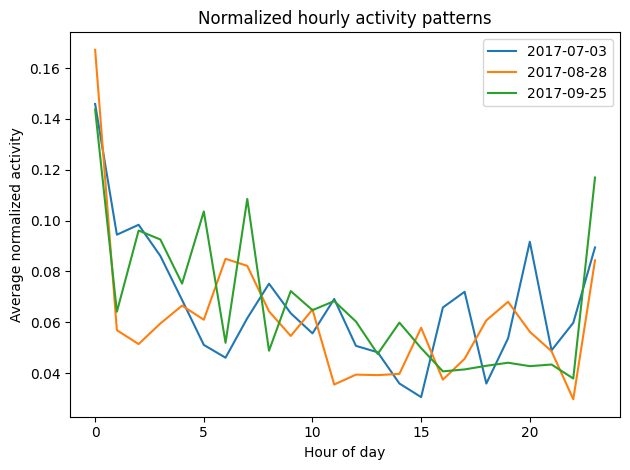

In [9]:
import matplotlib.pyplot as plt
agg_w1 = (
    hourly_w1.groupby("hour")["norm_count"] #group by hour and take the normalized activity column
             .mean() # average across cats to get one value per hour
             .reindex(range(24), fill_value=0)  # make sure that all 24 hours are represented
)

agg_w2 = (
    hourly_w2.groupby("hour")["norm_count"]
             .mean()
             .reindex(range(24), fill_value=0)
)
agg_w3 = (
    hourly_w3.groupby("hour")["norm_count"]
             .mean()
             .reindex(range(24), fill_value=0)
)

plt.figure()
plt.plot(range(24), agg_w1, label="2017-07-03")
plt.plot(range(24), agg_w2, label="2017-08-28")
plt.plot(range(24), agg_w3, label="2017-09-25")

plt.xlabel("Hour of day")
plt.ylabel("Average normalized activity")
plt.title("Normalized hourly activity patterns")
plt.legend()
plt.tight_layout()
plt.show()

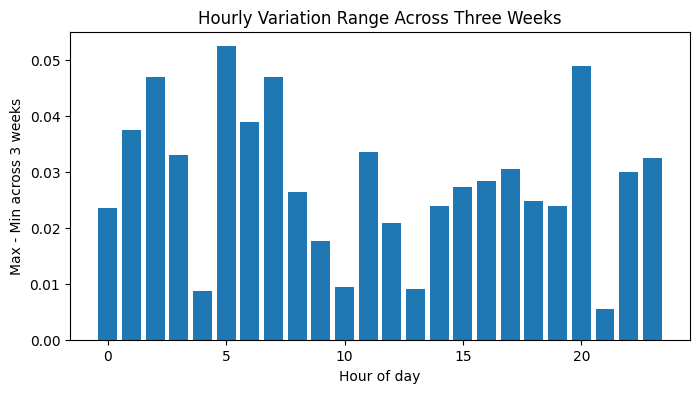

In [10]:
eda_matrix = pd.DataFrame({
    "week1": agg_w1.values,
    "week2": agg_w2.values,
    "week3": agg_w3.values
})

eda_matrix.index = range(24)
eda_matrix.head()
hourly_range = eda_matrix.max(axis=1) - eda_matrix.min(axis=1)

plt.figure(figsize=(8,4))
plt.bar(range(24), hourly_range)

plt.xlabel("Hour of day")
plt.ylabel("Max - Min across 3 weeks")
plt.title("Hourly Variation Range Across Three Weeks")
plt.show()

**4.PCA**

In [11]:
import pandas as pd
import numpy as np

# make the martix for the 24h pattern refer to 3 weeks seperately(refer to M2)
weekly_matrix = pd.DataFrame({
    "week1": agg_w1.values,
    "week2": agg_w2.values,
    "week3": agg_w3.values
}).T
weekly_matrix

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
week1,0.145886,0.094447,0.098352,0.086096,0.068755,0.051086,0.046045,0.061586,0.075167,0.063547,...,0.035895,0.030545,0.065814,0.071983,0.035876,0.053665,0.091678,0.048937,0.059779,0.089441
week2,0.167206,0.056871,0.051414,0.059513,0.066541,0.060988,0.084969,0.082185,0.064286,0.054608,...,0.039689,0.057819,0.037402,0.045616,0.060751,0.068049,0.056255,0.048587,0.029698,0.084364
week3,0.143698,0.064133,0.096084,0.092562,0.075201,0.103591,0.051917,0.108533,0.048788,0.072273,...,0.059847,0.049820,0.040674,0.041433,0.042866,0.044068,0.042720,0.043370,0.037861,0.116938


In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

scaler = StandardScaler()
matrix_scaled = scaler.fit_transform(weekly_matrix)

pca = PCA(n_components=3)
matrix_pca = pca.fit_transform(matrix_scaled)

pca_df = pd.DataFrame(
    matrix_pca,
    index=weekly_matrix.index,
    columns=["PC1", "PC2", "PC3"]
)

pca_df

,PC1,PC2,PC3
week1,-2.171415,-4.262625,-5.923832e-16
week2,5.058476,0.383930,-5.923832e-16
week3,-2.887061,3.878695,-5.923832e-16


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.7/458.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 42.4 MB/s eta 0:00:00


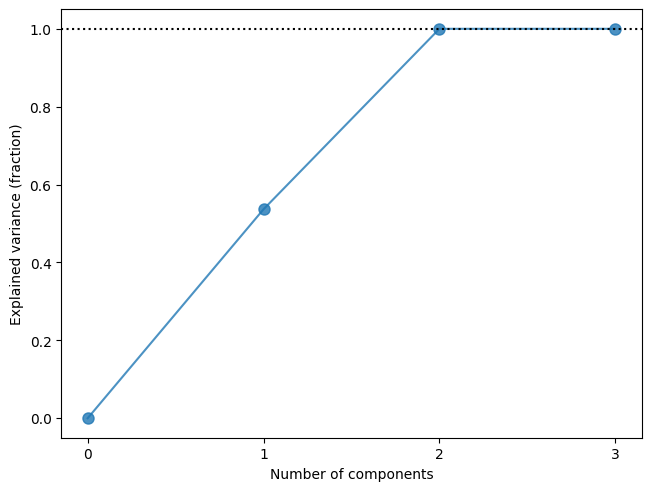

In [13]:
!pip install psynlig -q
from matplotlib import pyplot as plt
from psynlig import(
    pca_explained_variance,
    pca_explained_variance_bar,
)
_, ax = pca_explained_variance(
    pca,
    marker = "o",
    markersize = 8,
    alpha = 0.8
)
plt.show()

In [14]:
pca.explained_variance_ratio_

array([5.36643718e-01, 4.63356282e-01, 1.46215754e-32])

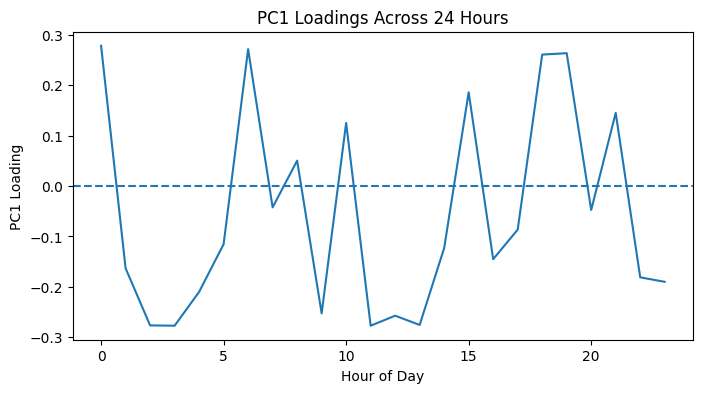

In [15]:
pca.components_
loadings = pd.DataFrame(
    pca.components_.T,
    index=range(24),
    columns=["PC1", "PC2", "PC3"]
)

plt.figure(figsize=(8,4))
plt.plot(loadings["PC1"])
plt.axhline(0, linestyle="--")
plt.xlabel("Hour of Day")
plt.ylabel("PC1 Loading")
plt.title("PC1 Loadings Across 24 Hours")
plt.show()
#I use AI assistance to check if my code is useful because I am not sure if I need to use the inverse of the matrix.

**5.k-means clustering**

In [16]:
#make the matrix for each week and combined together(refer to M2)
X1 = (
    hourly_w1
    .pivot(index="tag_id", columns="hour", values="norm_count")
    .fillna(0)
    .reindex(columns=range(24), fill_value=0)
    .copy()
)

X1["week"] = "week1"
X1["tag_id"] = X1.index
X1["cat_week_id"] = X1["tag_id"].astype(str) + "@week1"

X1 = X1.reset_index(drop=True)

X2 = (
    hourly_w2
    .pivot(index="tag_id", columns="hour", values="norm_count")
    .fillna(0)
    .reindex(columns=range(24), fill_value=0)
    .copy()
)

X2["week"] = "week2"
X2["tag_id"] = X2.index
X2["cat_week_id"] = X2["tag_id"].astype(str) + "@week2"
X2 = X2.reset_index(drop=True)

X3 = (
    hourly_w3
    .pivot(index="tag_id", columns="hour", values="norm_count")
    .fillna(0)
    .reindex(columns=range(24), fill_value=0)
    .copy()
)

X3["week"] = "week3"
X3["tag_id"] = X3.index
X3["cat_week_id"] = X3["tag_id"].astype(str) + "@week3"

X3 = X3.reset_index(drop=True)
combined = pd.concat([X1, X2, X3], ignore_index=True)

combined.head()

hour,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,week,tag_id,cat_week_id
0,0.038462,0.153846,0.076923,0.076923,0.038462,0.000000,0.019231,0.038462,0.096154,0.000000,...,0.038462,0.076923,0.115385,0.000000,0.000000,0.000000,0.115385,week1,Barney-Tag,Barney-Tag@week1
1,0.117647,0.047059,0.047059,0.094118,0.070588,0.023529,0.047059,0.070588,0.000000,0.000000,...,0.000000,0.023529,0.047059,0.094118,0.047059,0.094118,0.129412,week1,Carbonel-Tag,Carbonel-Tag@week1
2,0.190000,0.200000,0.190000,0.190000,0.130000,0.040000,0.040000,0.010000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.010000,week1,Charlie,Charlie@week1
3,0.138889,0.000000,0.027778,0.055556,0.000000,0.000000,0.055556,0.027778,0.111111,0.055556,...,0.013889,0.027778,0.027778,0.000000,0.111111,0.000000,0.083333,week1,Coco,Coco@week1
4,0.083333,0.083333,0.166667,0.125000,0.041667,0.000000,0.000000,0.083333,0.083333,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,week1,Fonzie-Tag,Fonzie-Tag@week1


In [17]:
#standardization
from sklearn.preprocessing import StandardScaler

feature_cols = list(range(24))
X = combined[feature_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [18]:
#test the value of k
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    inertia = kmeans.inertia_

    results.append({
        "k": k,
        "silhouette": sil,
        "inertia": inertia
    })

k_table = pd.DataFrame(results)
k_table
## I used AI assistance to test different k in one time and create a table instead of test k one by one. I get the formula of the "def" function of k and write the above code by myself.

,k,silhouette,inertia
0,2,0.123121,928.856502
1,3,0.092125,847.304103
2,4,0.084467,786.975069
3,5,0.092273,732.411986
4,6,0.073068,689.408488


In [19]:
#test the value of k
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

results = []

for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=21, n_init=40)
    labels = kmeans.fit_predict(X_scaled)

    sil = silhouette_score(X_scaled, labels)
    inertia = kmeans.inertia_

    results.append({
        "k": k,
        "silhouette": sil,
        "inertia": inertia
    })

k_table = pd.DataFrame(results)
k_table

,k,silhouette,inertia
0,2,0.123121,928.856502
1,3,0.102388,850.892329
2,4,0.105174,787.874593
3,5,0.078101,728.454338
4,6,0.091694,676.993186


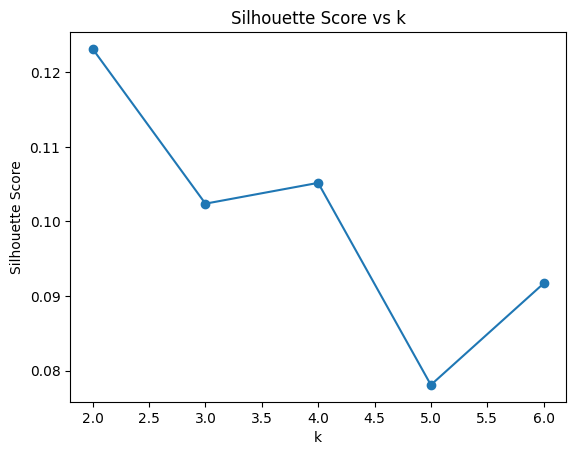

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(k_table["k"], k_table["silhouette"], marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs k")
plt.show()

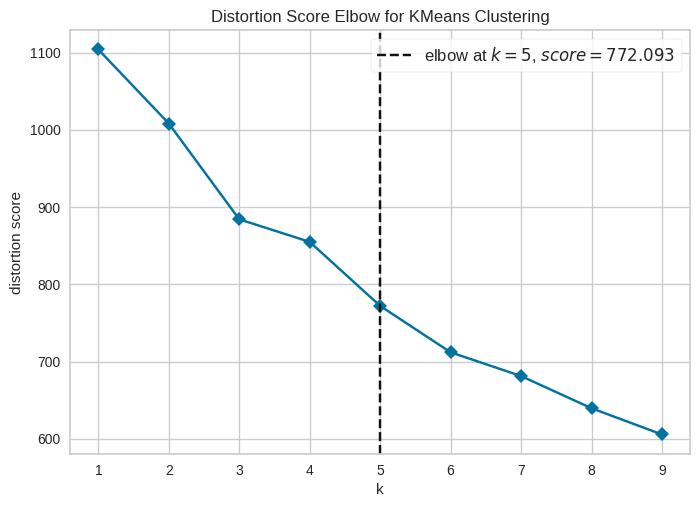

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [21]:
#elbow plot
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
model = KMeans(random_state=42)

visualizer = KElbowVisualizer(
    model,
    k=(1, 10),
    metric="distortion",
    timings=False
)
visualizer.fit(X_scaled)
visualizer.show()

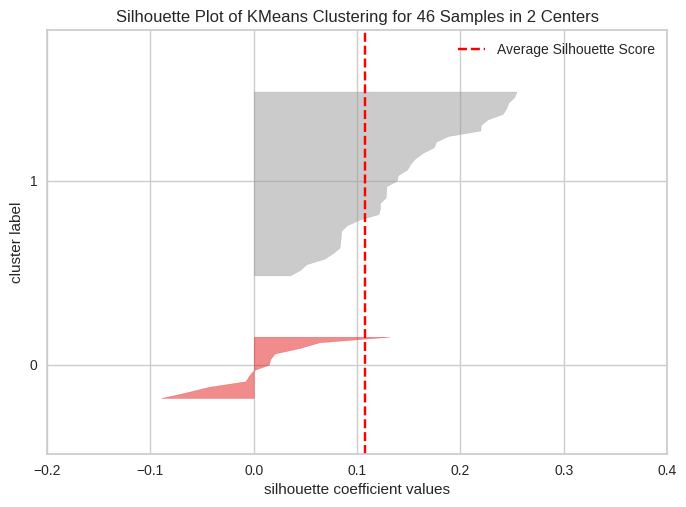

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 46 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [22]:
from sklearn.cluster import KMeans
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters=2, random_state=42)

visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)
visualizer.show()

In [23]:
k_final = 2
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=20)
combined["cluster"] = kmeans.fit_predict(X_scaled)

combined[["cat_week_id", "week", "cluster"]].head()

hour,cat_week_id,week,cluster
0,Barney-Tag@week1,week1,1
1,Carbonel-Tag@week1,week1,0
2,Charlie@week1,week1,0
3,Coco@week1,week1,1
4,Fonzie-Tag@week1,week1,0


In [24]:
ct_counts = pd.crosstab(combined["cluster"], combined["week"])
ct_counts
#I use AI assistance to learn about the function "crosstabl" and make this table of cluster × week.

week,week1,week2,week3
cluster,,,
0,7,5,8
1,9,11,6


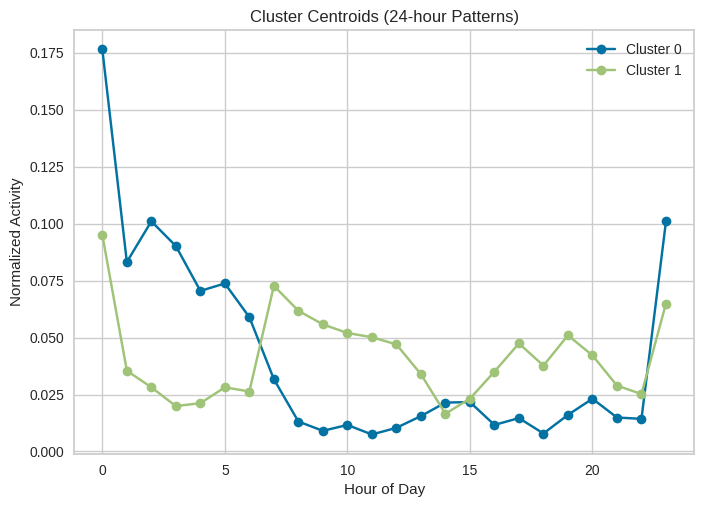

In [25]:
centers_scaled = kmeans.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

centers_df = pd.DataFrame(centers, columns=feature_cols)

plt.figure()
for c in range(k_final):
    plt.plot(range(24), centers_df.loc[c], marker="o", label=f"Cluster {c}")

plt.xlabel("Hour of Day")
plt.ylabel("Normalized Activity")
plt.title("Cluster Centroids (24-hour Patterns)")
plt.legend()
plt.show()
#I use AI assistance to learn about if the two-line graph will be available here,learn about it and understand it and write the code by my understanding.